# Data Exploration with R

**Learning Goal:** Use Claude Code to explore Bolivia's sustainable development data using R.

This notebook demonstrates:
- Loading data using project configuration
- Basic data inspection
- Summary statistics
- Identifying patterns and relationships

This is the R equivalent of `01_data_exploration.ipynb` (Python version).

## Setup

First, we load our project configuration and required libraries.

In [1]:
# Load project configuration
source('../config.R')

# Set seeds for reproducibility
set_seeds()

# Load required libraries
library(tidyverse)

cat("Data directory:", DATA_DIR, "\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Data directory: /Users/carlosmendez/Documents/GitHub/claude4data/data 


## Load the Datasets

We have 4 datasets that can be joined via `asdf_id`:
1. **regionNames** - Municipality identifiers
2. **sdg** - SDG index scores (0-100)
3. **sdgVariables** - Detailed SDG indicators
4. **ntl** - Night-time lights (economic proxy)

In [2]:
# Load all datasets
regions <- read_csv(file.path(DATA_DIR, 'regionNames', 'regionNames.csv'), show_col_types = FALSE)
sdg <- read_csv(file.path(DATA_DIR, 'sdg', 'sdg.csv'), show_col_types = FALSE)
sdg_vars <- read_csv(file.path(DATA_DIR, 'sdgVariables', 'sdgVariables.csv'), show_col_types = FALSE)
ntl <- read_csv(file.path(DATA_DIR, 'ntl', 'ln_NTLpc.csv'), show_col_types = FALSE)

cat("Regions:", dim(regions), "\n")
cat("SDG indices:", dim(sdg), "\n")
cat("SDG variables:", dim(sdg_vars), "\n")
cat("Night-time lights:", dim(ntl), "\n")

Regions: 339 8 


SDG indices: 339 17 


SDG variables: 339 65 


Night-time lights: 339 19 


## Inspect the Data

Let's look at each dataset's structure.

In [3]:
# Region names - administrative metadata
cat("=== REGION NAMES ===", "\n")
head(regions)
cat("\nColumns:", names(regions), "\n")

=== REGION NAMES === 


poly_id,asdf_id,mun,mun_id,dep,dep_id,dep_mun,shapeID
<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
178,0,Esmeralda,40505,Oruro,5,Oruro-Esmeralda,BOL-ADM3-33444609B20338026
169,1,Quillacas,40202,Oruro,5,Oruro-Quillacas,BOL-ADM3-33444609B53994240
185,2,Pampa Aullagas,40802,Oruro,5,Oruro-Pampa Aullagas,BOL-ADM3-33444609B27878331
205,3,Llallagua,50203,Potosí,7,Potosí-Llallagua,BOL-ADM3-33444609B13957296
219,4,Caripuyo,50702,Potosí,7,Potosí-Caripuyo,BOL-ADM3-33444609B2060227
118,5,Aiquile,30201,Cochabamba,3,Cochabamba-Aiquile,BOL-ADM3-33444609B22499454



Columns: poly_id asdf_id mun mun_id dep dep_id dep_mun shapeID 


In [4]:
# SDG indices - composite scores
cat("=== SDG INDICES ===", "\n")
head(sdg)
cat("\nColumns:", names(sdg), "\n")

=== SDG INDICES === 


asdf_id,imds,index_sdg1,index_sdg2,index_sdg3,index_sdg4,index_sdg5,index_sdg6,index_sdg7,index_sdg8,index_sdg9,index_sdg10,index_sdg11,index_sdg13,index_sdg15,index_sdg16,index_sdg17
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,53.2,34.76,55.08,85.69,68.86,58.53,34.54,52.23,30.92,24.53,83.94,32.56,77.38,50.00,82.40,26.889999
1,50.5,27.95,34.82,70.20,57.73,87.53,21.84,50.11,56.60,46.64,74.09,30.68,75.44,50.00,69.72,4.380000
2,47.3,18.91,54.58,72.82,48.72,77.48,22.48,45.45,35.47,28.93,76.00,25.33,74.61,50.00,69.22,9.770001
3,58.1,60.48,34.73,72.26,66.89,72.97,53.05,69.36,47.44,60.15,66.57,48.88,87.62,50.00,69.27,12.030000
4,43.5,18.89,32.19,59.92,49.67,77.06,33.66,36.00,49.00,16.34,41.64,31.68,77.53,50.00,74.14,4.240000
5,50.4,41.88,30.07,73.92,56.17,75.69,36.41,46.43,43.34,42.88,44.03,37.82,86.45,61.19,69.64,9.590000



Columns: asdf_id imds index_sdg1 index_sdg2 index_sdg3 index_sdg4 index_sdg5 index_sdg6 index_sdg7 index_sdg8 index_sdg9 index_sdg10 index_sdg11 index_sdg13 index_sdg15 index_sdg16 index_sdg17 


In [5]:
# Night-time lights - economic activity proxy
cat("=== NIGHT-TIME LIGHTS ===", "\n")
head(ntl)
cat("\nColumns:", names(ntl), "\n")

=== NIGHT-TIME LIGHTS === 


asdf_id,ln_NTLpc2012,ln_NTLpc2013,ln_NTLpc2014,ln_NTLpc2015,ln_NTLpc2016,ln_NTLpc2017,ln_NTLpc2018,ln_NTLpc2019,ln_NTLpc2020,ln_t400NTLpc2012,ln_t400NTLpc2013,ln_t400NTLpc2014,ln_t400NTLpc2015,ln_t400NTLpc2016,ln_t400NTLpc2017,ln_t400NTLpc2018,ln_t400NTLpc2019,ln_t400NTLpc2020
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,11.72947,12.11182,10.96202,11.69920,13.08561,13.64719,13.66768,13.59544,13.48928,11.41418,11.72649,12.03933,12.35454,12.67127,12.98705,13.30042,13.61158,13.92167
1,12.96552,13.14276,13.07450,13.14308,12.94834,13.82188,13.82232,13.80377,14.01637,12.86293,12.99937,13.13605,13.27361,13.41252,13.55291,13.69378,13.83477,13.97586
2,12.76306,12.92760,12.87628,12.19994,12.28914,13.40614,13.35825,12.98208,13.72283,12.54725,12.64321,12.73968,12.83794,12.93959,13.04464,13.15148,13.25941,13.36822
3,14.27502,14.39553,14.49086,14.51870,14.76335,14.82730,14.90234,14.96020,14.87075,14.31098,14.40044,14.48976,14.57877,14.66735,14.75521,14.84229,14.92874,15.01482
4,11.70900,12.14277,11.80942,11.97687,11.59005,12.51004,12.69435,12.80766,13.15037,11.61288,11.77262,11.93282,12.09469,12.25909,12.42662,12.59619,12.76693,12.93819
5,14.10600,14.15592,14.09832,14.24966,14.41263,14.60651,14.69456,14.66778,14.75852,14.03804,14.13244,14.22697,14.32188,14.41709,14.51233,14.60733,14.70205,14.79668



Columns: asdf_id ln_NTLpc2012 ln_NTLpc2013 ln_NTLpc2014 ln_NTLpc2015 ln_NTLpc2016 ln_NTLpc2017 ln_NTLpc2018 ln_NTLpc2019 ln_NTLpc2020 ln_t400NTLpc2012 ln_t400NTLpc2013 ln_t400NTLpc2014 ln_t400NTLpc2015 ln_t400NTLpc2016 ln_t400NTLpc2017 ln_t400NTLpc2018 ln_t400NTLpc2019 ln_t400NTLpc2020 


## Merge Datasets

Create a combined dataset for analysis using dplyr joins.

In [6]:
# Merge all datasets on asdf_id
df <- regions %>%
  left_join(sdg, by = 'asdf_id') %>%
  left_join(ntl, by = 'asdf_id')

cat("Combined dataset:", dim(df), "\n")
cat("\nColumns:", names(df), "\n")

Combined dataset: 339 42 



Columns: poly_id asdf_id mun mun_id dep dep_id dep_mun shapeID imds index_sdg1 index_sdg2 index_sdg3 index_sdg4 index_sdg5 index_sdg6 index_sdg7 index_sdg8 index_sdg9 index_sdg10 index_sdg11 index_sdg13 index_sdg15 index_sdg16 index_sdg17 ln_NTLpc2012 ln_NTLpc2013 ln_NTLpc2014 ln_NTLpc2015 ln_NTLpc2016 ln_NTLpc2017 ln_NTLpc2018 ln_NTLpc2019 ln_NTLpc2020 ln_t400NTLpc2012 ln_t400NTLpc2013 ln_t400NTLpc2014 ln_t400NTLpc2015 ln_t400NTLpc2016 ln_t400NTLpc2017 ln_t400NTLpc2018 ln_t400NTLpc2019 ln_t400NTLpc2020 


## Summary Statistics

Explore the distribution of SDG indices across Bolivia's municipalities.

In [7]:
# SDG index columns
sdg_cols <- names(df)[str_starts(names(df), 'index_sdg')]
cat("SDG indices:", sdg_cols, "\n\n")

# Summary statistics
df %>%
  select(all_of(sdg_cols)) %>%
  summary()

SDG indices: index_sdg1 index_sdg2 index_sdg3 index_sdg4 index_sdg5 index_sdg6 index_sdg7 index_sdg8 index_sdg9 index_sdg10 index_sdg11 index_sdg13 index_sdg15 index_sdg16 index_sdg17 



   index_sdg1      index_sdg2      index_sdg3      index_sdg4   
 Min.   : 0.06   Min.   :21.44   Min.   :50.23   Min.   :12.37  
 1st Qu.:21.64   1st Qu.:30.78   1st Qu.:70.38   1st Qu.:46.61  
 Median :34.76   Median :37.98   Median :76.17   Median :54.38  
 Mean   :37.46   Mean   :40.68   Mean   :75.21   Mean   :53.25  
 3rd Qu.:51.88   3rd Qu.:49.11   3rd Qu.:80.75   3rd Qu.:61.11  
 Max.   :90.46   Max.   :71.37   Max.   :89.05   Max.   :85.82  
   index_sdg5      index_sdg6      index_sdg7      index_sdg8   
 Min.   :37.79   Min.   : 0.00   Min.   :24.94   Min.   :14.95  
 1st Qu.:68.28   1st Qu.:25.49   1st Qu.:40.95   1st Qu.:38.12  
 Median :74.24   Median :34.92   Median :50.15   Median :45.20  
 Mean   :73.06   Mean   :35.80   Mean   :52.26   Mean   :44.98  
 3rd Qu.:79.62   3rd Qu.:44.70   3rd Qu.:62.29   3rd Qu.:51.92  
 Max.   :93.54   Max.   :95.01   Max.   :96.53   Max.   :72.51  
   index_sdg9     index_sdg10     index_sdg11     index_sdg13   
 Min.   : 0.62   Min.   :

In [8]:
# Overall development index (IMDS)
cat("=== Municipal Sustainable Development Index (IMDS) ===", "\n")
summary(df$imds)

cat("\nTop 5 municipalities:\n")
df %>%
  select(mun, dep, imds) %>%
  arrange(desc(imds)) %>%
  head(5)

=== Municipal Sustainable Development Index (IMDS) === 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  35.70   47.00   50.50   51.05   54.85   80.20 


Top 5 municipalities:


mun,dep,imds
<chr>,<chr>,<dbl>
La Paz,La Paz,80.2
Cochabamba,Cochabamba,73.7
Tarija,Tarija,70.6
Quillacollo,Cochabamba,69.8
Sucre,Chuquisaca,69.6


In [9]:
# Department-level summary
cat("=== IMDS by Department ===", "\n")
df %>%
  group_by(dep) %>%
  summarise(
    mean = mean(imds, na.rm = TRUE),
    sd = sd(imds, na.rm = TRUE),
    min = min(imds, na.rm = TRUE),
    max = max(imds, na.rm = TRUE),
    count = n()
  ) %>%
  arrange(desc(mean))

=== IMDS by Department === 


dep,mean,sd,min,max,count
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Tarija,60.60000,5.500000,51.8,70.6,11
Santa Cruz,54.28929,4.798018,42.7,64.1,56
Cochabamba,52.50213,8.501803,39.4,73.7,47
La Paz,50.97816,5.374756,41.8,80.2,87
Oruro,50.68286,5.027073,42.9,67.4,35
Beni,50.47368,4.503806,43.9,61.3,19
Chuquisaca,47.79655,6.603596,35.7,69.6,29
Potosí,47.40250,7.553144,36.3,66.2,40
Pando,45.43333,5.592554,36.4,57.1,15


## Quick Visualizations

Using ggplot2 for elegant visualizations.


Attaching package: ‘gridExtra’




The following object is masked from ‘package:dplyr’:

    combine




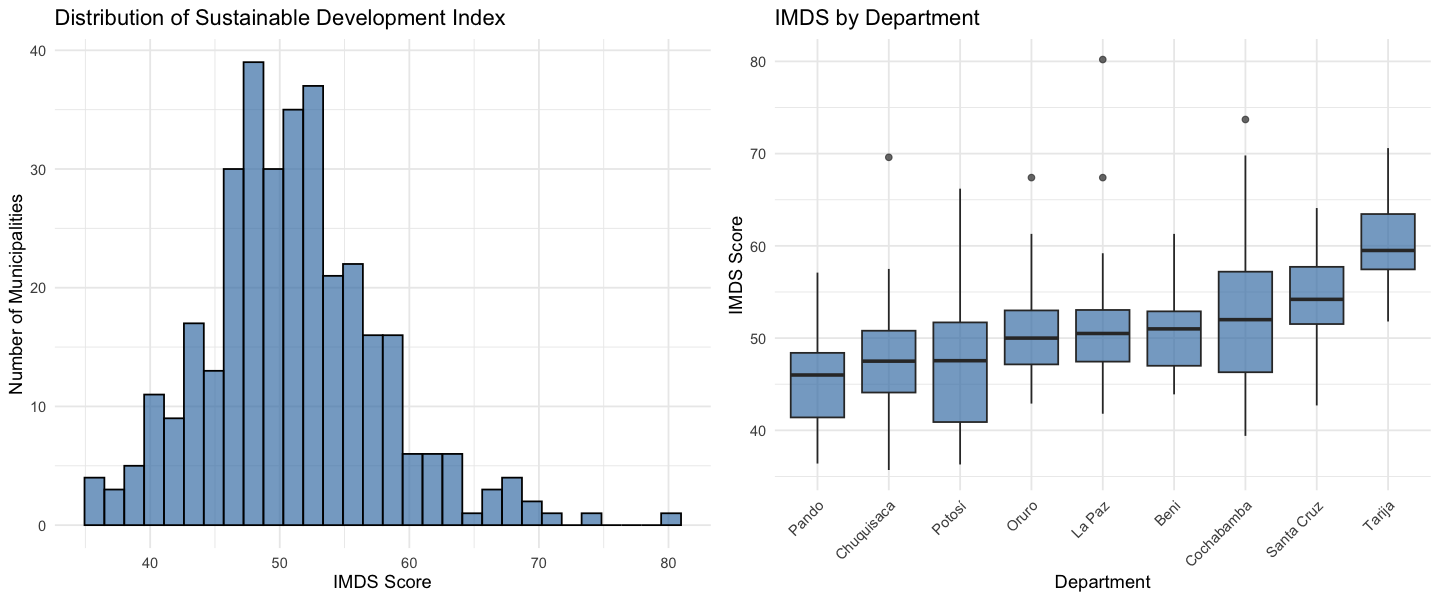

In [10]:
# Set plot size for Jupyter
options(repr.plot.width = 12, repr.plot.height = 5)

# Distribution of IMDS - Histogram
p1 <- ggplot(df, aes(x = imds)) +
  geom_histogram(bins = 30, fill = 'steelblue', color = 'black', alpha = 0.7) +
  labs(
    title = 'Distribution of Sustainable Development Index',
    x = 'IMDS Score',
    y = 'Number of Municipalities'
  ) +
  theme_minimal()

# Boxplot by department
p2 <- ggplot(df, aes(x = reorder(dep, imds, FUN = median), y = imds)) +
  geom_boxplot(fill = 'steelblue', alpha = 0.7) +
  labs(
    title = 'IMDS by Department',
    x = 'Department',
    y = 'IMDS Score'
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Combine plots side by side
library(gridExtra)
grid.arrange(p1, p2, ncol = 2)

Plot saved to: /Users/carlosmendez/Documents/GitHub/claude4data/output/imds_distribution_R.png 


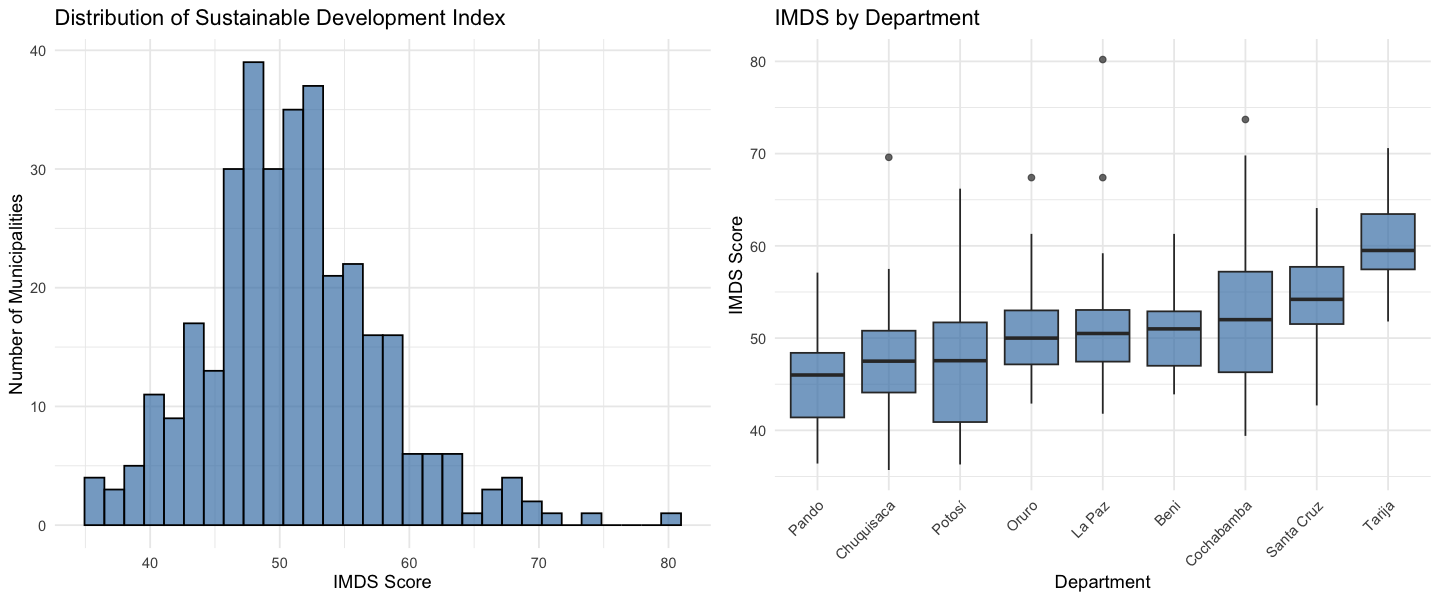

In [11]:
# Save the plot
ggsave(
  filename = file.path(OUTPUT_DIR, 'imds_distribution_R.png'),
  plot = grid.arrange(p1, p2, ncol = 2),
  width = 12,
  height = 5,
  dpi = 150
)
cat("Plot saved to:", file.path(OUTPUT_DIR, 'imds_distribution_R.png'), "\n")

## Your Turn!

Try asking Claude Code to help you with:
- "Show me the correlation between SDG indices using corrplot"
- "Which municipalities have the lowest SDG1 (poverty) scores?"
- "Plot night-time lights over time for a specific department"
- "Create a faceted plot comparing SDG indices across departments"

In [12]:
# Space for your exploration
